<div style="background: linear-gradient(135deg, #1c0f13 0%, #3b1f2b 50%, #6b3a4d 100%); padding: 38px 30px; border-radius: 16px; text-align: center;">
  <h1 style="color: #f2d7ee; font-size: 2.3em; margin: 0; letter-spacing: 2px;">🌳 Decision Tree — Skin Dataset</h1>
  <p style="color: #d4a5c9; font-size: 1.1em; margin-top: 12px;">
    <strong>Model A</strong> — DT Classifier &nbsp;→&nbsp; predict <code>Skin_Type</code> (Dry · Normal · Oily)<br/>
    <strong>Model B</strong> — DT Regressor &nbsp;&nbsp;→&nbsp; predict <code>skin_score</code> (continuous)
  </p>
  <hr style="border: 1px solid #d4a5c9; width: 55%; margin: 18px auto;"/>
  <p style="color: #aaa; font-size: 0.88em;">Preprocessing · Baseline · GridSearchCV · Tree Plot · Feature Importance · Summary</p>
</div>

---
## ⚙️ Step 1 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree            import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    plot_tree, export_text
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics       import roc_curve, auc, roc_auc_score

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
C1, C2, C3 = '#3b1f2b', '#c9184a', '#6b9080'

print('✅ Libraries ready.')

✅ Libraries ready.


---
## 📂 Step 2 — Load & Preprocess

In [2]:
# Adjust filename / path as needed
# On Colab: from google.colab import files; files.upload()
df = pd.read_csv('Skin_Type_dataset.csv')   # ← adapt

print(f'Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols')
df.head(3)

Shape   : 10,000 rows × 10 cols


,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,skin_score,skin_age
0,31,Female,Medium,High,Low,53.0,16.9,Oily,100.0,15.0
1,42,Male,Low,Low,High,32.6,15.4,Dry,36.8,62.0
2,36,Male,Medium,Medium,Low,65.5,14.0,Normal,100.0,24.5


In [3]:
# ── Encode categorical features ──────────────────────────────────────────────
df_enc = df.copy()

cat_cols = ['Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity']
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

# Encode target
le_target = LabelEncoder()
df_enc['Skin_Type_enc'] = le_target.fit_transform(df_enc['Skin_Type'])
CLASS_NAMES = le_target.classes_

print(f'Skin_Type classes : {list(CLASS_NAMES)}')

# ── Features / targets ───────────────────────────────────────────────────────
FEATURES = ['Age', 'Gender', 'Hydration_Level', 'Oil_Level',
            'Sensitivity', 'Humidity', 'Temperature']

X     = df_enc[FEATURES]
y_clf = df_enc['Skin_Type_enc']
y_reg = df_enc['skin_score']

# ── Train / Test splits ──────────────────────────────────────────────────────
# Note: Decision Trees don't need scaling
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.20, random_state=42)

print(f'Train : {X_train_c.shape[0]} samples  |  Test : {X_test_c.shape[0]} samples')
print('✅ No scaling needed — Decision Trees are scale-invariant.')

Skin_Type classes : ['Combination', 'Dry', 'Normal', 'Oily']
Train : 8000 samples  |  Test : 2000 samples
✅ No scaling needed — Decision Trees are scale-invariant.


---
## 🅰️ Model A — Decision Tree Classifier  →  `Skin_Type`

### 3-A · Baseline model

In [4]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_c, y_train_c)

y_pred_base_c = dt_base.predict(X_test_c)
acc_base      = accuracy_score(y_test_c, y_pred_base_c)

cv_base = cross_val_score(dt_base, X, y_clf, cv=5, scoring='accuracy').mean()

print(f'Baseline Depth      : {dt_base.get_depth()}')
print(f'Baseline Test Acc   : {acc_base:.4f}  ({acc_base*100:.2f}%)')
print(f'Baseline CV-5 Acc   : {cv_base:.4f}')

Baseline Depth      : 27
Baseline Test Acc   : 0.6840  (68.40%)
Baseline CV-5 Acc   : 0.6868


### 3-B · Depth vs Accuracy — finding the sweet spot

Best depth (test acc): 5  →  Accuracy = 0.7930


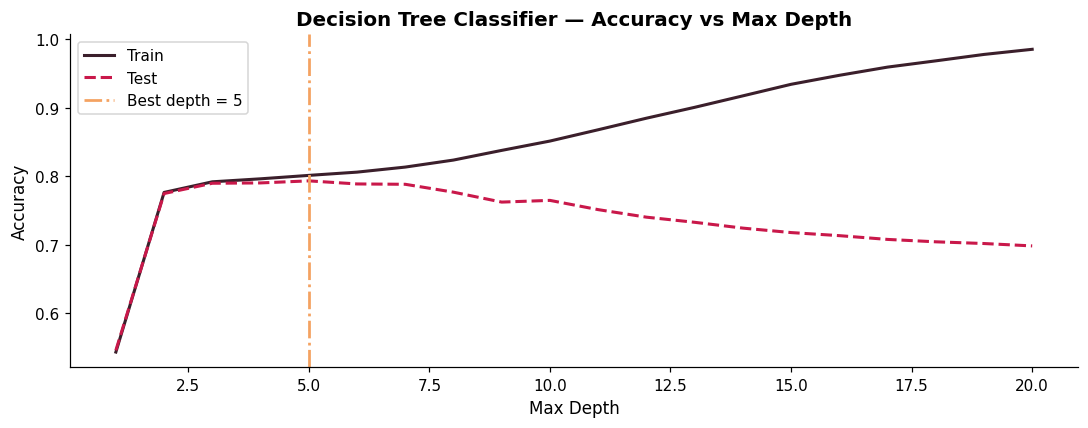

In [5]:
depths      = range(1, 21)
train_accs  = []
test_accs   = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_c, y_train_c)
    train_accs.append(accuracy_score(y_train_c, dt.predict(X_train_c)))
    test_accs.append(accuracy_score(y_test_c,   dt.predict(X_test_c)))

best_depth_clf = depths.start + int(np.argmax(test_accs))
print(f'Best depth (test acc): {best_depth_clf}  →  Accuracy = {max(test_accs):.4f}')

plt.figure(figsize=(10, 4))
plt.plot(depths, train_accs, label='Train', color=C1, linewidth=2)
plt.plot(depths, test_accs,  label='Test',  color=C2, linewidth=2, linestyle='--')
plt.axvline(best_depth_clf, color='#f4a261', linestyle='-.', linewidth=1.8,
            label=f'Best depth = {best_depth_clf}')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Classifier — Accuracy vs Max Depth', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 3-C · GridSearchCV — simple & fast

In [6]:
# Kept small on purpose — runs in seconds
param_grid_clf = {
    'max_depth'       : [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'criterion'       : ['gini', 'entropy']
}
# 5 × 3 × 2 = 30 combos × cv=5 → 150 fits

gs_clf = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_clf,
    cv=5, scoring='accuracy', n_jobs=-1
)
gs_clf.fit(X_train_c, y_train_c)

best_dt_clf = gs_clf.best_estimator_
y_pred_clf  = best_dt_clf.predict(X_test_c)
acc_clf     = accuracy_score(y_test_c, y_pred_clf)

print(f'Best params  : {gs_clf.best_params_}')
print(f'CV accuracy  : {gs_clf.best_score_:.4f}')
print(f'Test accuracy: {acc_clf:.4f}  ({acc_clf*100:.2f}%)')
print(f'Tree depth   : {best_dt_clf.get_depth()}')

Best params  : {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
CV accuracy  : 0.7917
Test accuracy: 0.7930  (79.30%)
Tree depth   : 5


### 3-D · Evaluation plots

In [7]:
print(classification_report(y_test_c, y_pred_clf, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

 Combination       0.53      0.21      0.30       294
         Dry       0.91      0.95      0.93       500
      Normal       0.74      0.88      0.81       617
        Oily       0.80      0.85      0.82       589

    accuracy                           0.79      2000
   macro avg       0.75      0.72      0.72      2000
weighted avg       0.77      0.79      0.77      2000



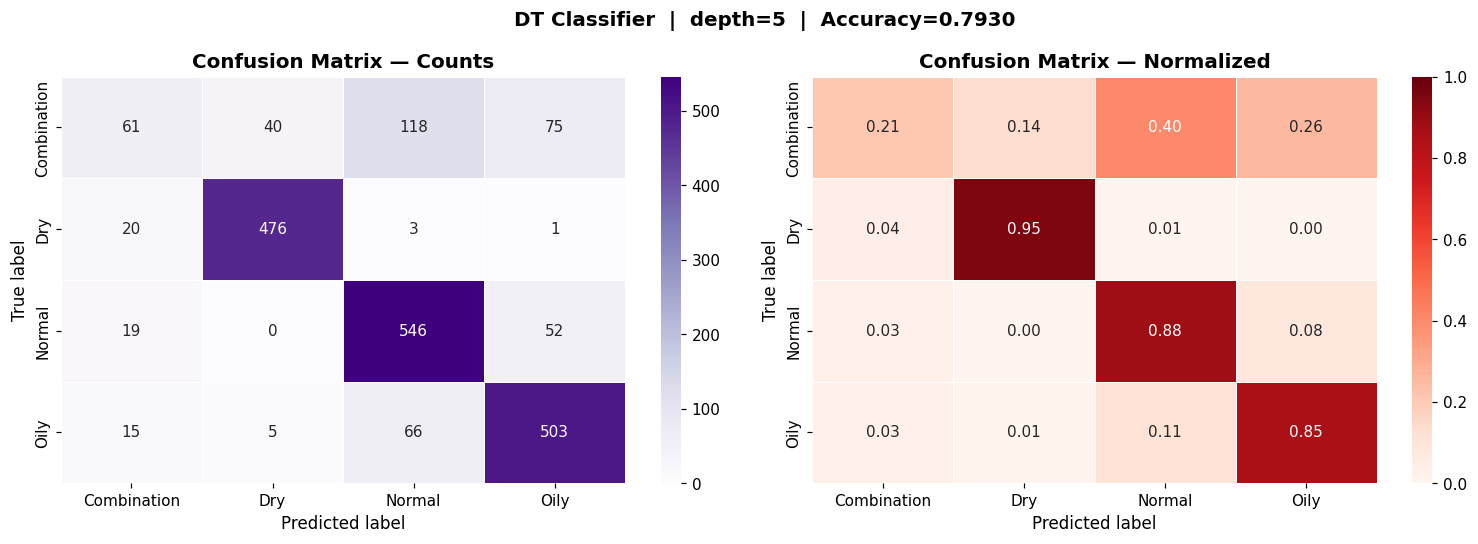

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_test_c, y_pred_clf)
cm_n = cm.astype(float) / cm.sum(axis=1)[:, None]

sns.heatmap(cm,   annot=True, fmt='d',   cmap='Purples', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix — Counts',     fontweight='bold')
axes[0].set_ylabel('True label'); axes[0].set_xlabel('Predicted label')

sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Reds',    ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Normalized', fontweight='bold')
axes[1].set_ylabel('True label'); axes[1].set_xlabel('Predicted label')

plt.suptitle(f'DT Classifier  |  depth={best_dt_clf.get_depth()}  |  Accuracy={acc_clf:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

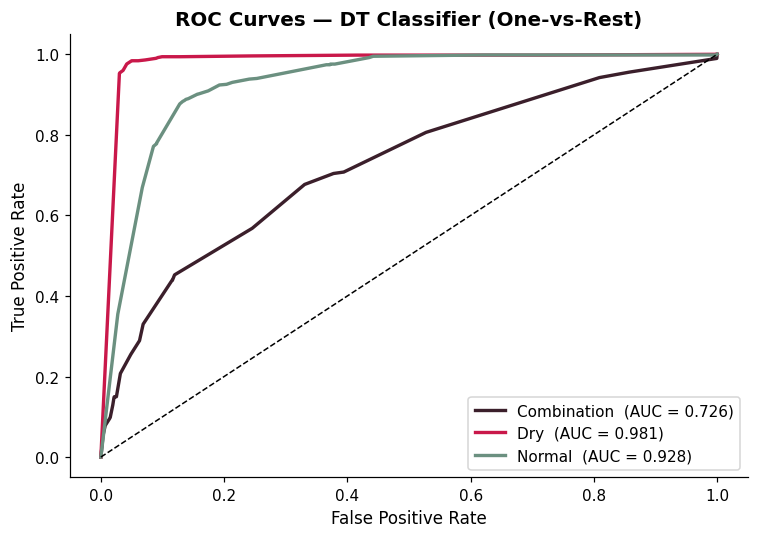

Macro-average AUC : 0.8928


In [9]:
y_test_bin  = label_binarize(y_test_c, classes=list(range(len(CLASS_NAMES))))
y_prob_clf  = best_dt_clf.predict_proba(X_test_c)
roc_colors  = [C1, C2, C3]

plt.figure(figsize=(7, 5))
for i, (cls, col) in enumerate(zip(CLASS_NAMES, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_clf[:, i])
    plt.plot(fpr, tpr, color=col, linewidth=2.2,
             label=f'{cls}  (AUC = {auc(fpr,tpr):.3f})')

plt.plot([0,1],[0,1],'k--',linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — DT Classifier (One-vs-Rest)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_prob_clf, multi_class='ovr', average='macro')
print(f'Macro-average AUC : {macro_auc:.4f}')

### 3-E · Tree visualization & Feature Importance

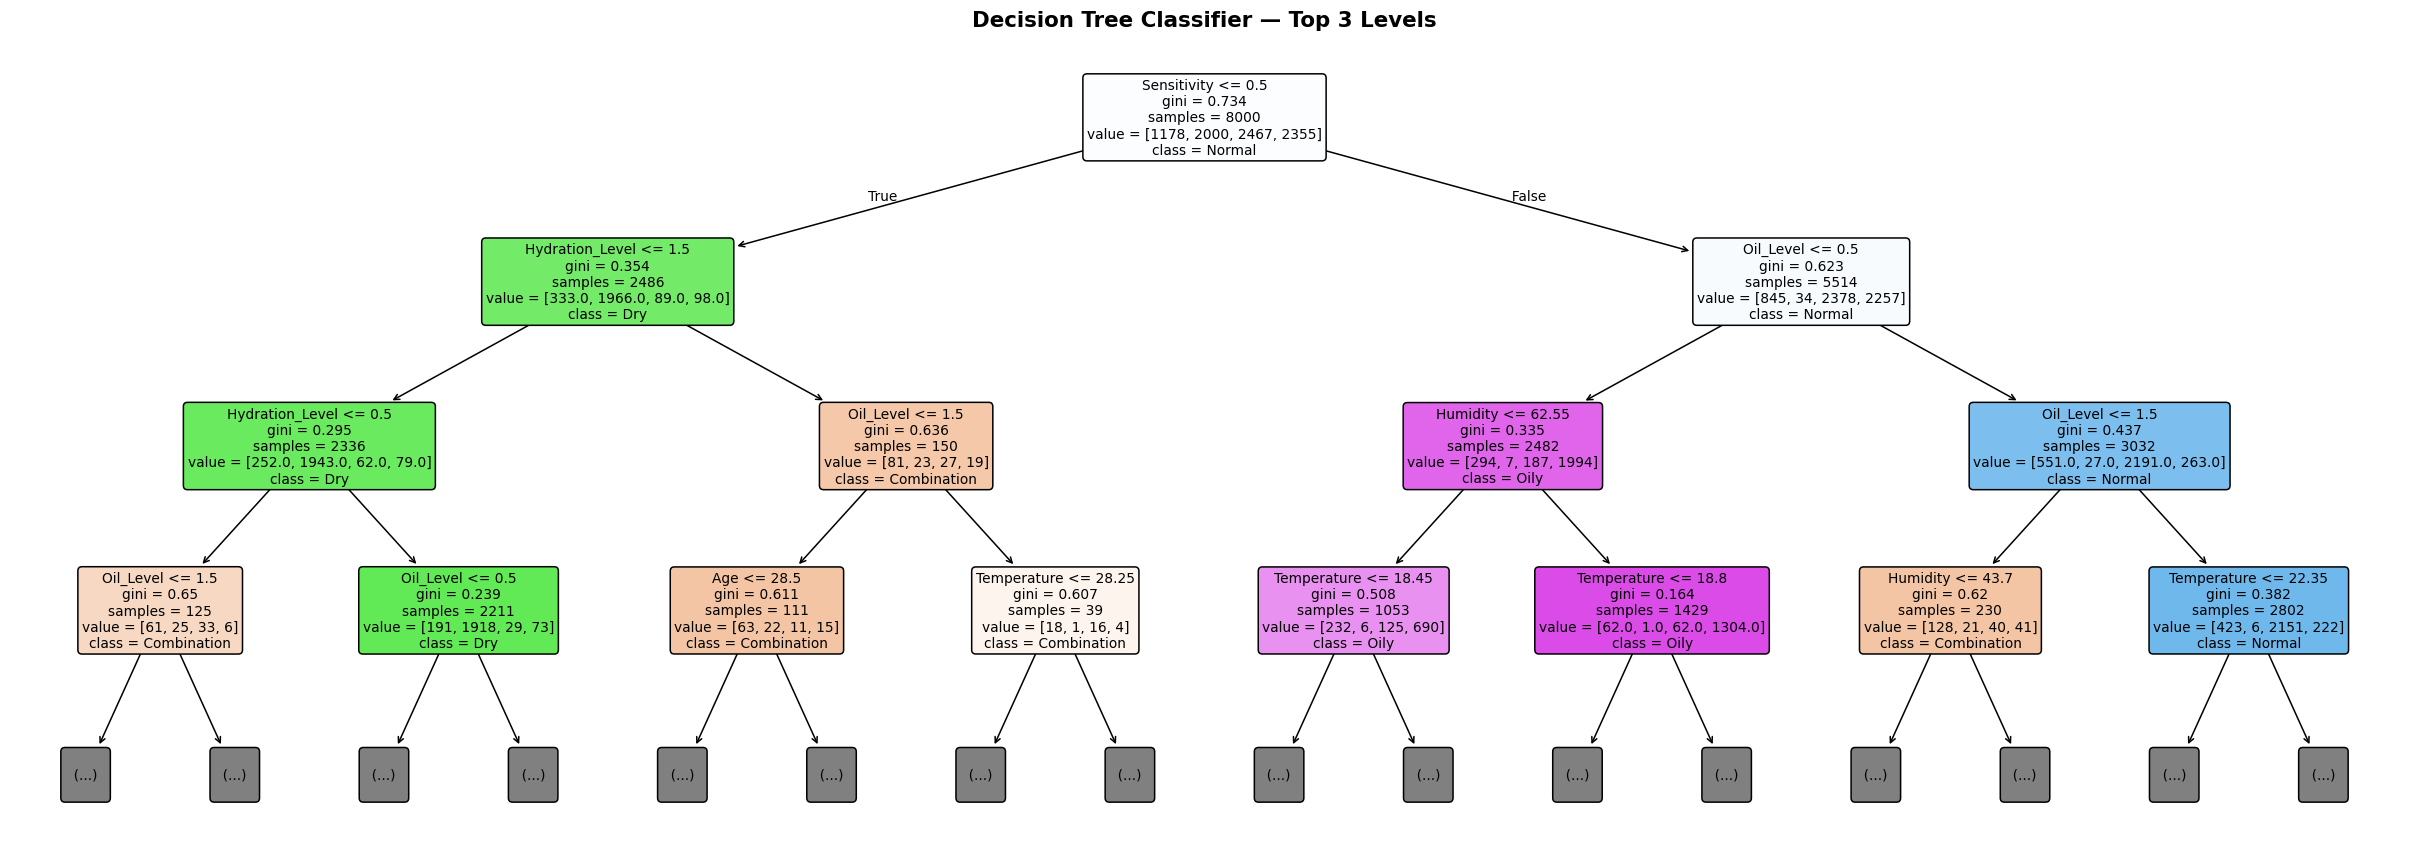

In [10]:
# ── Visual tree (capped at depth 3 for readability) ─────────────────────────
plt.figure(figsize=(22, 8))
plot_tree(
    best_dt_clf,
    feature_names = FEATURES,
    class_names   = CLASS_NAMES,
    filled        = True,
    max_depth     = 3,          # show only top 3 levels
    fontsize      = 9,
    rounded       = True,
    impurity      = True
)
plt.title('Decision Tree Classifier — Top 3 Levels', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

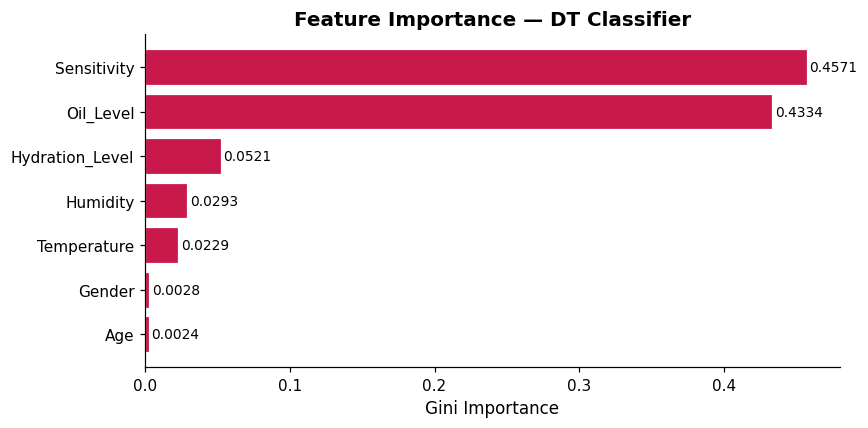

In [11]:
imp_df_c = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_dt_clf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(imp_df_c['Feature'], imp_df_c['Importance'],
                color=C2, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, imp_df_c['Importance']):
    plt.text(v + 0.002, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.xlabel('Gini Importance')
plt.title('Feature Importance — DT Classifier', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🅱️ Model B — Decision Tree Regressor  →  `skin_score`

### 4-A · Baseline model

In [12]:
dt_reg_base = DecisionTreeRegressor(random_state=42)
dt_reg_base.fit(X_train_r, y_train_r)

y_pred_base_r = dt_reg_base.predict(X_test_r)
rmse_base = np.sqrt(mean_squared_error(y_test_r, y_pred_base_r))
r2_base   = r2_score(y_test_r, y_pred_base_r)

print(f'Baseline Depth : {dt_reg_base.get_depth()}')
print(f'Baseline RMSE  : {rmse_base:.4f}')
print(f'Baseline R²    : {r2_base:.4f}')

Baseline Depth : 29
Baseline RMSE  : 6.6718
Baseline R²    : 0.9388


### 4-B · Depth vs RMSE — finding the sweet spot

Best depth (min test RMSE): 8  →  RMSE=5.1113  R²=0.9641


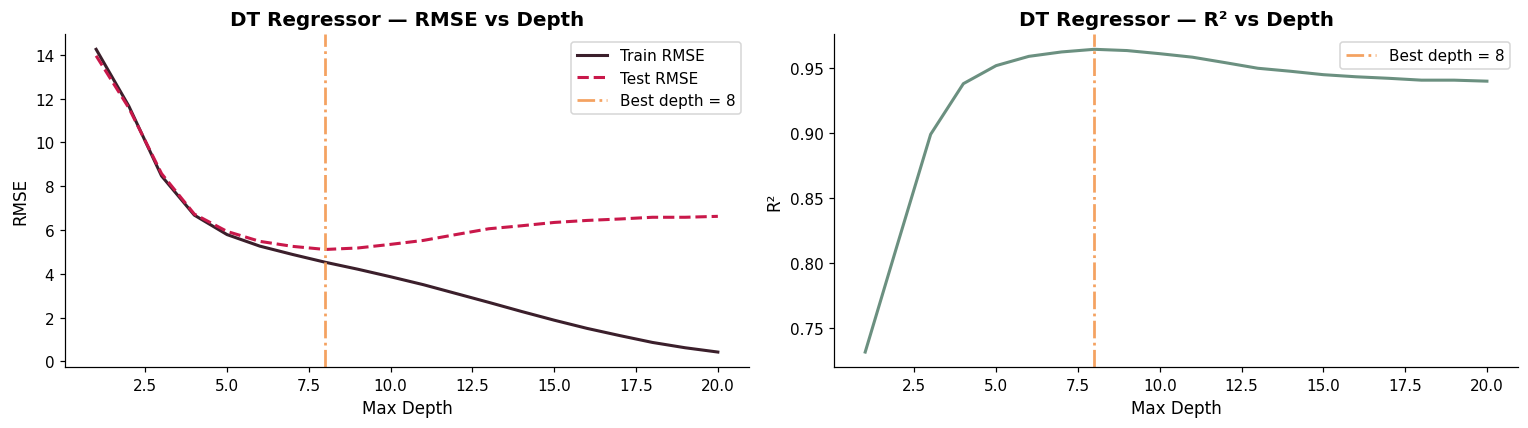

In [13]:
depths_r    = range(1, 21)
train_rmses = []
test_rmses  = []
test_r2s    = []

for d in depths_r:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train_r, y_train_r)
    train_rmses.append(np.sqrt(mean_squared_error(y_train_r, dt.predict(X_train_r))))
    preds = dt.predict(X_test_r)
    test_rmses.append(np.sqrt(mean_squared_error(y_test_r, preds)))
    test_r2s.append(r2_score(y_test_r, preds))

best_depth_reg = depths_r.start + int(np.argmin(test_rmses))
print(f'Best depth (min test RMSE): {best_depth_reg}  →  RMSE={min(test_rmses):.4f}  R²={test_r2s[best_depth_reg-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(depths_r, train_rmses, label='Train RMSE', color=C1, linewidth=2)
axes[0].plot(depths_r, test_rmses,  label='Test RMSE',  color=C2, linewidth=2, linestyle='--')
axes[0].axvline(best_depth_reg, color='#f4a261', linestyle='-.', linewidth=1.8,
                label=f'Best depth = {best_depth_reg}')
axes[0].set_xlabel('Max Depth'); axes[0].set_ylabel('RMSE')
axes[0].set_title('DT Regressor — RMSE vs Depth', fontweight='bold')
axes[0].legend()

axes[1].plot(depths_r, test_r2s, color=C3, linewidth=2)
axes[1].axvline(best_depth_reg, color='#f4a261', linestyle='-.', linewidth=1.8,
                label=f'Best depth = {best_depth_reg}')
axes[1].set_xlabel('Max Depth'); axes[1].set_ylabel('R²')
axes[1].set_title('DT Regressor — R² vs Depth', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4-C · GridSearchCV — simple & fast

In [14]:
param_grid_reg = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf' : [1, 5, 10]
}
# 5 × 3 × 3 = 45 combos × cv=5 → 225 fits — very fast

gs_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_reg,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
gs_reg.fit(X_train_r, y_train_r)

best_dt_reg = gs_reg.best_estimator_
y_pred_reg  = best_dt_reg.predict(X_test_r)

rmse_reg = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
mae_reg  = mean_absolute_error(y_test_r, y_pred_reg)
r2_reg   = r2_score(y_test_r, y_pred_reg)

print(f'Best params : {gs_reg.best_params_}')
print(f'Tree depth  : {best_dt_reg.get_depth()}')
print(f'RMSE : {rmse_reg:.4f}')
print(f'MAE  : {mae_reg:.4f}')
print(f'R²   : {r2_reg:.4f}')

Best params : {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
Tree depth  : 10
RMSE : 5.1693
MAE  : 3.4322
R²   : 0.9632


### 4-D · Evaluation plots

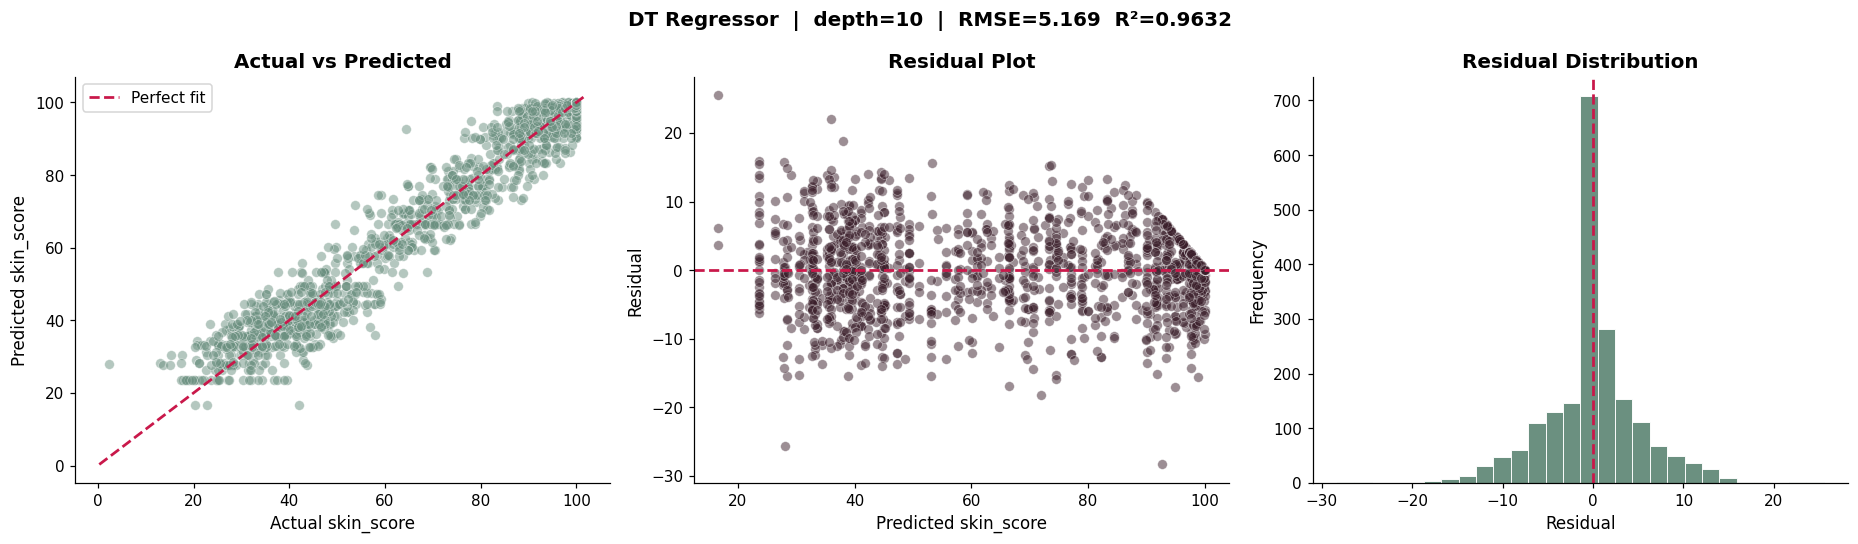

In [15]:
residuals = y_test_r.values - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Actual vs Predicted
axes[0].scatter(y_test_r, y_pred_reg, alpha=0.5, color=C3,
                edgecolors='white', linewidth=0.4, s=40)
lims = [min(y_test_r.min(), y_pred_reg.min())-2,
        max(y_test_r.max(), y_pred_reg.max())+2]
axes[0].plot(lims, lims, '--', color=C2, linewidth=1.8, label='Perfect fit')
axes[0].set_xlabel('Actual skin_score'); axes[0].set_ylabel('Predicted skin_score')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
axes[1].scatter(y_pred_reg, residuals, alpha=0.5, color=C1,
                edgecolors='white', linewidth=0.4, s=40)
axes[1].axhline(0, color=C2, linestyle='--', linewidth=1.8)
axes[1].set_xlabel('Predicted skin_score'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', fontweight='bold')

# Residual distribution
axes[2].hist(residuals, bins=28, color=C3, edgecolor='white', linewidth=0.6)
axes[2].axvline(0, color=C2, linestyle='--', linewidth=1.8)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.suptitle(
    f'DT Regressor  |  depth={best_dt_reg.get_depth()}  |  RMSE={rmse_reg:.3f}  R²={r2_reg:.4f}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4-E · Tree visualization & Feature Importance

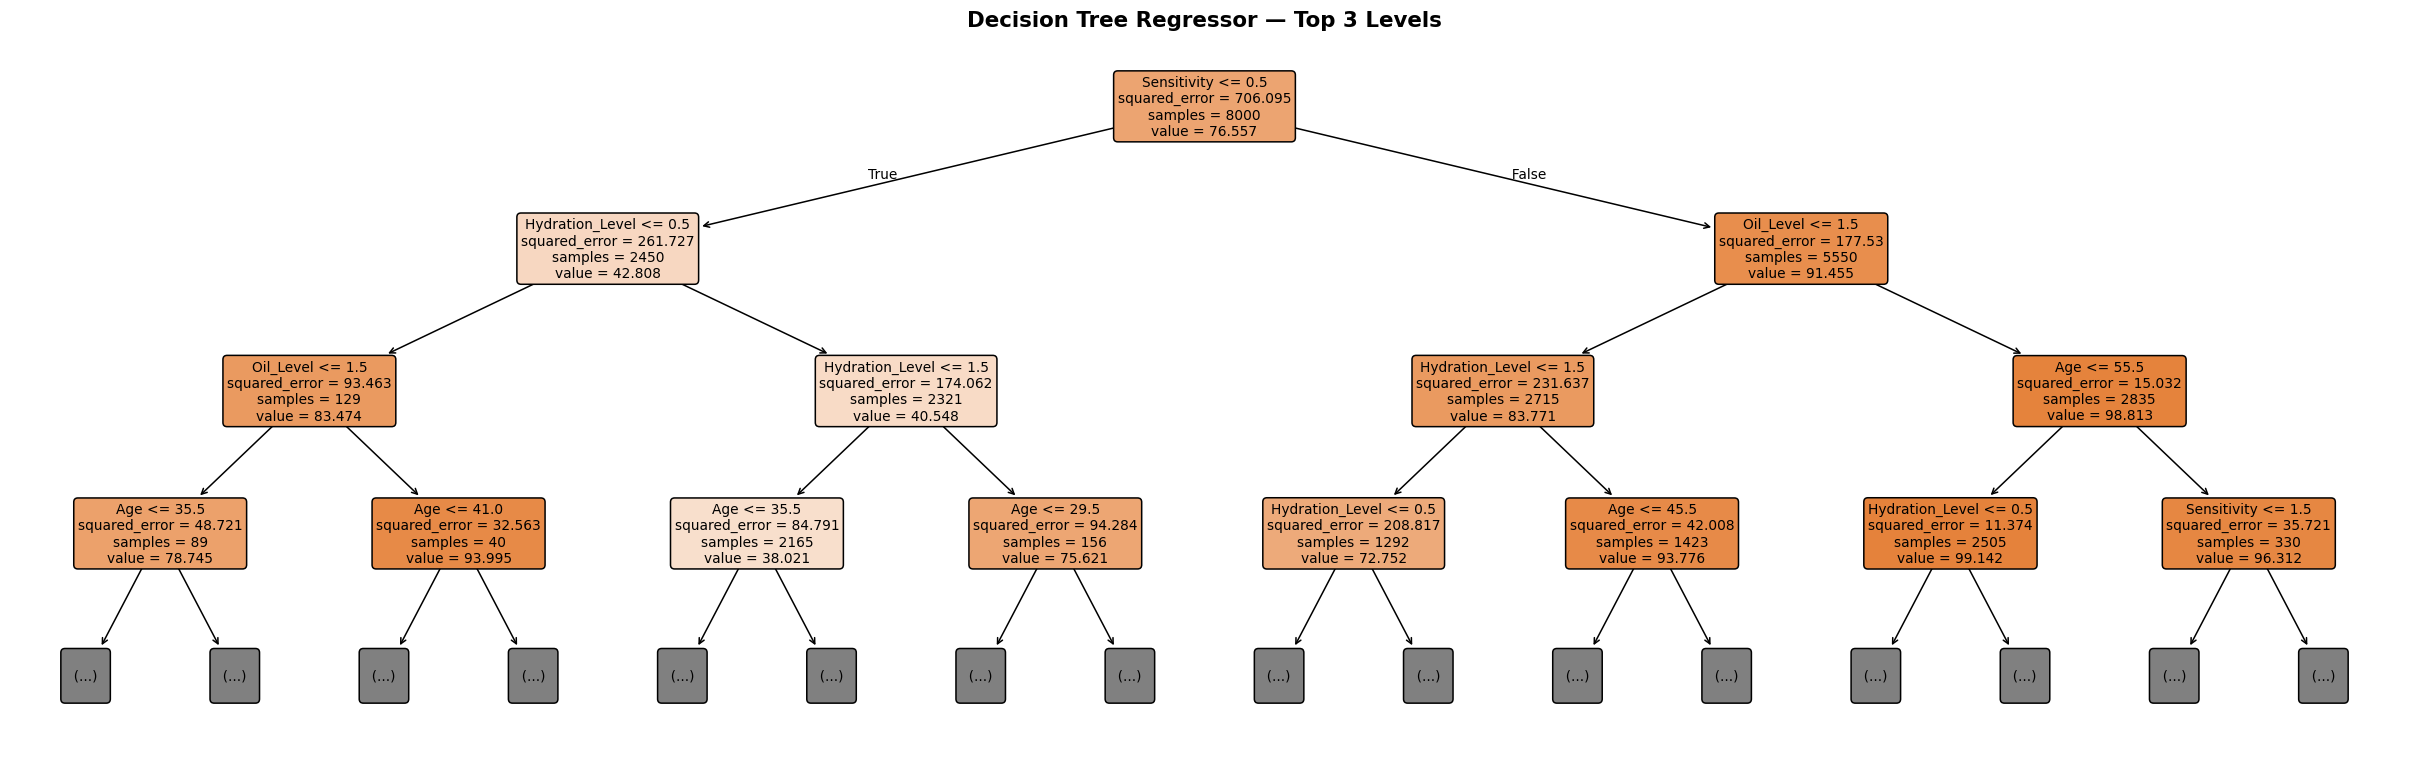

In [16]:
plt.figure(figsize=(22, 7))
plot_tree(
    best_dt_reg,
    feature_names = FEATURES,
    filled        = True,
    max_depth     = 3,
    fontsize      = 9,
    rounded       = True,
    impurity      = True
)
plt.title('Decision Tree Regressor — Top 3 Levels', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

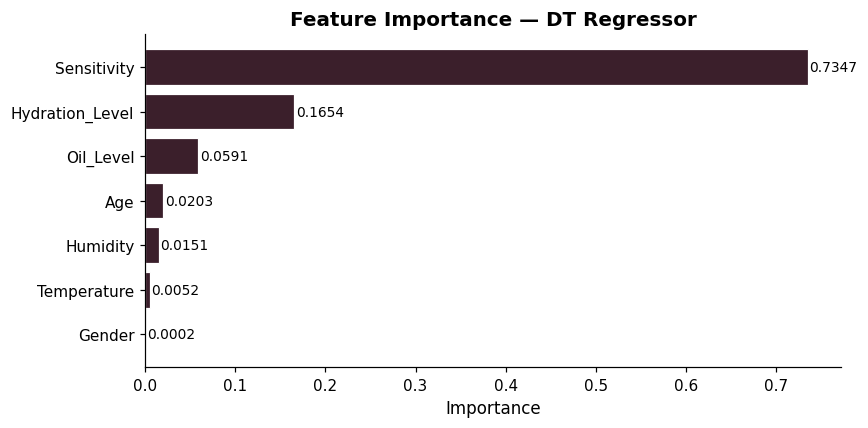

In [17]:
imp_df_r = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_dt_reg.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(imp_df_r['Feature'], imp_df_r['Importance'],
                color=C1, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, imp_df_r['Importance']):
    plt.text(v + 0.002, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.xlabel('Importance')
plt.title('Feature Importance — DT Regressor', fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Step 5 — Final Results Summary

In [18]:
summary = pd.DataFrame([
    {
        'Model'           : 'DT Classifier',
        'Target'          : 'Skin_Type',
        'Best depth'      : best_dt_clf.get_depth(),
        'Criterion'       : gs_clf.best_params_['criterion'],
        'Min split'       : gs_clf.best_params_['min_samples_split'],
        'Accuracy'        : f"{acc_clf*100:.2f}%",
        'AUC (macro)'     : f"{macro_auc:.4f}",
        'RMSE'            : '—',
        'R²'              : '—'
    },
    {
        'Model'           : 'DT Regressor',
        'Target'          : 'skin_score',
        'Best depth'      : best_dt_reg.get_depth(),
        'Criterion'       : 'squared_error',
        'Min split'       : gs_reg.best_params_['min_samples_split'],
        'Accuracy'        : '—',
        'AUC (macro)'     : '—',
        'RMSE'            : f"{rmse_reg:.4f}",
        'R²'              : f"{r2_reg:.4f}"
    }
])

print('='*72)
print('  DECISION TREE MODELS — FINAL RESULTS')
print('='*72)
print(summary.to_string(index=False))
print('='*72)

  DECISION TREE MODELS — FINAL RESULTS
        Model     Target  Best depth     Criterion  Min split Accuracy AUC (macro)   RMSE     R²
DT Classifier  Skin_Type           5          gini          2   79.30%      0.8928      —      —
 DT Regressor skin_score          10 squared_error         20        —           — 5.1693 0.9632


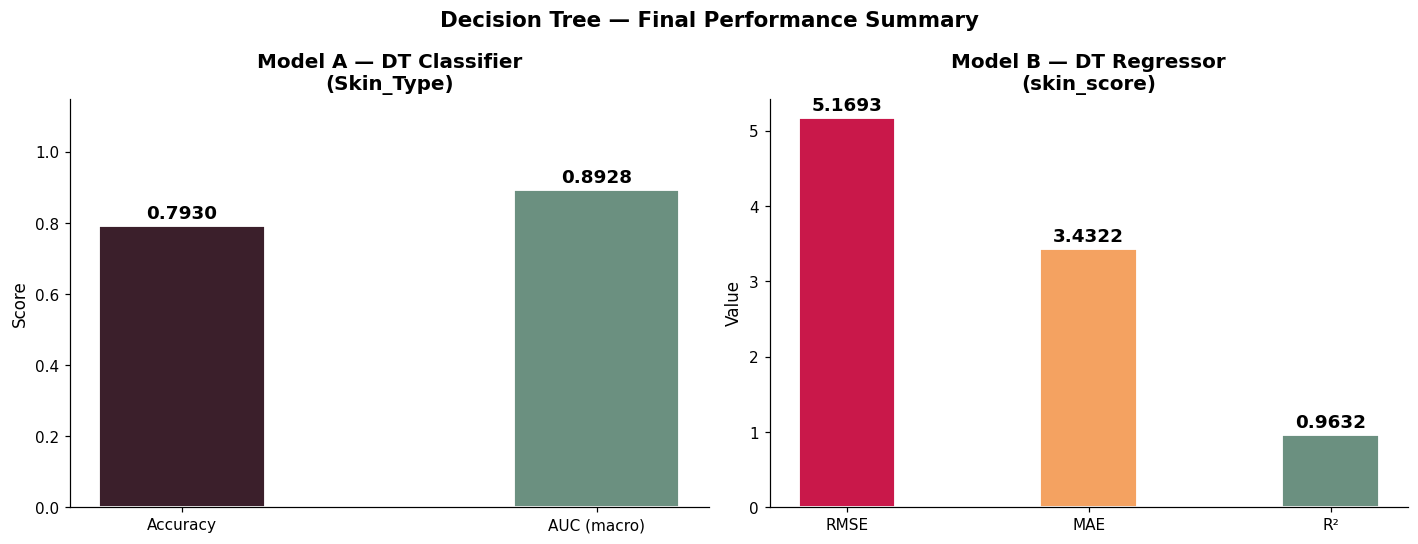

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Classifier ───────────────────────────────────────────────────────────────
metrics_c = ['Accuracy', 'AUC (macro)']
values_c  = [acc_clf,    macro_auc]
bars = axes[0].bar(metrics_c, values_c, color=[C1, C3],
                   edgecolor='white', linewidth=1.2, width=0.4)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Model A — DT Classifier\n(Skin_Type)', fontweight='bold')
axes[0].set_ylabel('Score')
for bar, v in zip(bars, values_c):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# ── Regressor ────────────────────────────────────────────────────────────────
metrics_r = ['RMSE', 'MAE', 'R²']
values_r  = [rmse_reg, mae_reg, r2_reg]
bars2 = axes[1].bar(metrics_r, values_r,
                    color=[C2, '#f4a261', C3],
                    edgecolor='white', linewidth=1.2, width=0.4)
axes[1].set_title('Model B — DT Regressor\n(skin_score)', fontweight='bold')
axes[1].set_ylabel('Value')
for bar, v in zip(bars2, values_r):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + max(values_r)*0.02,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Decision Tree — Final Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()